In [3]:
import random
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms, datasets as tv_datasets

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import CLIPVisionModel, CLIPProcessor
from torchvision import transforms as T

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

SEED = 1
random.seed(1); np.random.seed(1); torch.manual_seed(1)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(1)


Dataset - Pokemon

In [4]:
pokemon_dataset = load_dataset("diffusers/pokemon-gpt4-captions", split="train")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a1df3b486d3a28(…):   0%|          | 0.00/51.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/833 [00:00<?, ? examples/s]

In [5]:
pokemon_dataset.features

{'image': Image(mode=None, decode=True), 'text': Value('string')}

A cheerful Bulbasaur ready for its next Pokémon adventure.


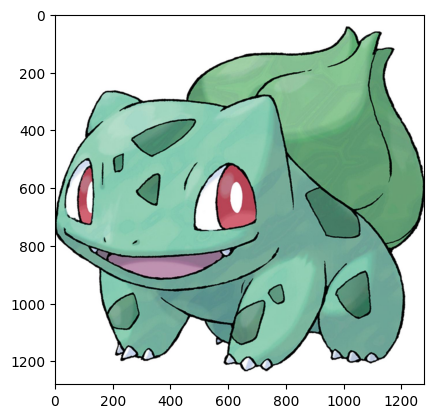

In [9]:
plt.imshow(pokemon_dataset[0]['image'])
print(pokemon_dataset[0]['text'])

In [ ]:
pokemons2 = pokemon_dataset.shuffle(seed=SEED).select(range(8))


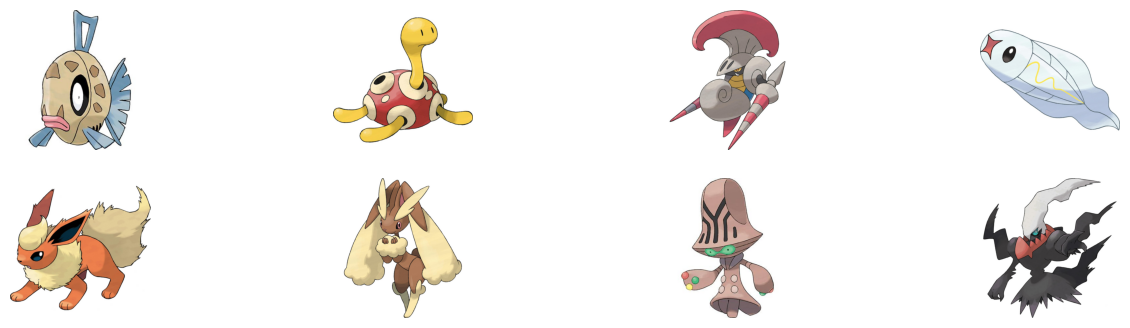

In [25]:
_, axes = plt.subplots(2, 4, figsize=(16, 4))
for ax, pokemon in zip(axes.flatten(), pokemons2):
    ax.imshow(pokemon['image'])
    ax.axis('off')
plt.show()

In [27]:
cnn_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

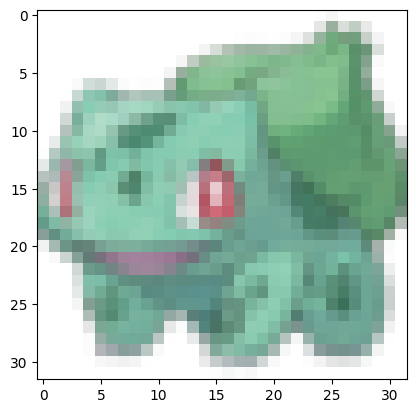

In [30]:
w_h = 32
img = T.Resize((w_h, w_h))(pokemon_dataset[0]['image'])

plt.imshow(img)
plt.show()

In [ ]:
n_teste = 8
n_treino = len(pokemon_dataset) - n_teste
n_treino


825

In [26]:
len(pokemon_data)

NameError: name 'pokemon_data' is not defined

In [23]:
train_data = pokemon_dataset.select(range(n_treino))
test_data = pokemon_dataset.select(range(n_treino, n_treino + n_teste))

In [24]:
len(train_data), len(test_data)

(825, 8)

In [28]:
train_img = torch.stack([cnn_transform(pokemon['image']) for pokemon in train_data])
train_descricao = [pokemon['text'] for pokemon in train_data]

test_img_originals = [pokemon['image'] for pokemon in test_data]
test_img = torch.stack([cnn_transform(pokemon['image']) for pokemon in test_data])
test_descricao = [pokemon['text'] for pokemon in test_data]

In [29]:
print(train_img.shape)
print(len(train_descricao))

print(len(test_img_originals))
print(test_img.shape)
print(len(test_descricao))



torch.Size([825, 3, 32, 32])
825
8
torch.Size([8, 3, 32, 32])
8


In [38]:
llama_tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
llama = AutoModelForCausalLM.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0", torch_dtype=torch.float16).to(device)
llama.eval()

for p in llama.parameters():
    p.requires_grad = False


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [39]:
sum(p.numel() for p in llama.parameters())

1100048384

In [40]:
llama.config.hidden_size, llama.config.vocab_size

(2048, 32000)

In [42]:
eos = llama_tokenizer.eos_token_id

In [43]:
frase_teste= llama_tokenizer("olá teste").input_ids
frase_teste

[1, 13386, 29976, 1243, 29872]

In [44]:
print([llama_tokenizer.decode([i]) for i in frase_teste])

['<s>', 'ol', 'á', 'test', 'e']


In [45]:
train_tokens = []
for descricao in train_descricao:
    train_tokens.append(llama_tokenizer(descricao).input_ids + [eos])

In [ ]:
len

In [46]:
train_descricao_lenghts = torch.tensor([len(i) for i in train_tokens])
max_len = train_descricao_lenghts.max().item()

In [47]:
max_len

65

In [48]:
train_tokens = torch.tensor([texto + [eos] * (max_len - len(texto)) for texto in train_tokens])

In [49]:
train_tokens.shape

torch.Size([825, 65])

In [50]:
train_tokens[0]

tensor([    1,   319, 22794,  1319,  8313,  6500,  6698,  7960,   363,   967,
         2446, 21747,  2249,   265, 17623,   545, 29889,     2,     2,     2,
            2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     2,     2,     2])

In [51]:
class PokemonCNN(nn.Module):
    def __init__(self, out_channels=128):
        super().__init__()
        channels = [3, 32, 64, out_channels]

        def block(self, in_channel, out_channel):
            return nn.Sequential(
                nn.Conv2d(in_channel, out_channel, 3, stride=2, padding=1),
                nn.BatchNorm2d(out_channel),
                nn.ReLU(),
                nn.Conv2d(in_channel, out_channel, 3, stride=2, padding=1),
                nn.BatchNorm2d(out_channel),
                nn.ReLU()
        )

        self.block1 = nn.Sequential(*[block(self, channels[i], channels[i+1]) for i in range(len(channels)-1)])

    def forward(self, x):
        x = self.block1(x)
        return x.flatten(2).transpose(1, 2)


NameError: name 'nn' is not defined

In [ ]:
cnn_encoder = PokemonCNN().to(device)
projector = nn.Linear(128, llama.config.hidden_size).to(device)

In [ ]:
train_dataset = TensorDataset(train_img, train_tokens, train_descricao_lenghts)
loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
opt = torch.optim.Adam(projector.parameters(), lr=1e-3)